# Computing Tempered Energy 

We aim to implement a parallel tempering scheme for annealed MCMC as per Du et al.'s [2024 paper](https://arxiv.org/pdf/2302.11552) on compositional generation with energy-based diffusion. In order to implement parallel tempering into the sampling regime of annealed MCMC, we aim to evaluate the difference between true tempered energy and our approximations.

Training follows standard DDPM noise-matching objective

### Setup

In [1]:
from src.eval import plot_temperature_triptych

In [2]:
steps = {
    0:  100,
    1:   99,
    2:   98,
    3:   96,
    4:   95,
    5:   94,
    6:   92,
    7:   90,
    8:   89,
    9:   87,
    10:  85,
    11:  83,
    12:  81,
    13:  79,
    14:  76,
    15:  74,
    16:  71,
    17:  68,
    18:  65,
    19:  61,
    20:  58,
    21:  54,
    22:  49,
    23:  44,
    24:  39,
    25:  33,
    26:  26,
    27:  19,
    28:  10,
    29:   1,
}

In [3]:
lam = 1.2
n_replicas = 2
n_samples = 1

swap_algorithm = {
	"p_ratio" : "p",
	"odd":   [ steps[0], steps[4], steps[8],  steps[12], steps[14], steps[16], steps[18], steps[20], steps[22]],
	"even":  [ steps[2], steps[6], steps[10], steps[13], steps[15], steps[17], steps[19], steps[21], steps[23]],
	"debug" : True
}

# Composed Dataset

 diff 1.0004363059997559


/n/netscratch/kempner_undergrads/Everyone/zwu/parallel_toy/toy/src/score_integral.py:112: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


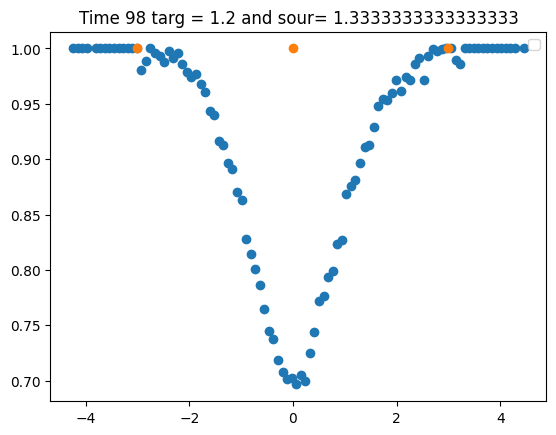

p ratio.         0.8110771179199219 std 0.2772023677825928
Time 98 swap btwn source 1.33 and target 1.20 accept 0.81 
 diff 1.0112923383712769


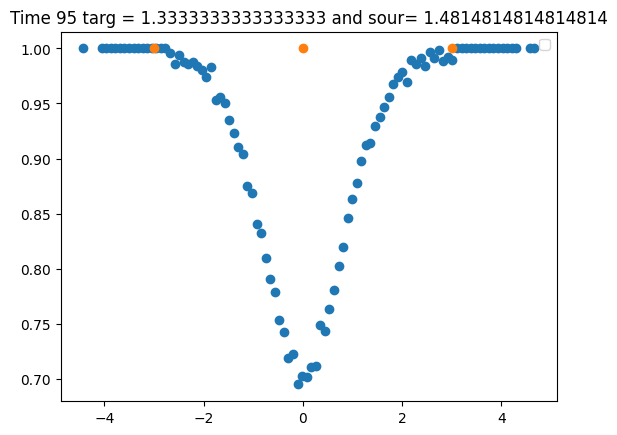

p ratio.         0.8180578947067261 std 0.2724289000034332
Time 95 swap btwn source 1.48 and target 1.33 accept 0.82 
 diff 1.01948881149292


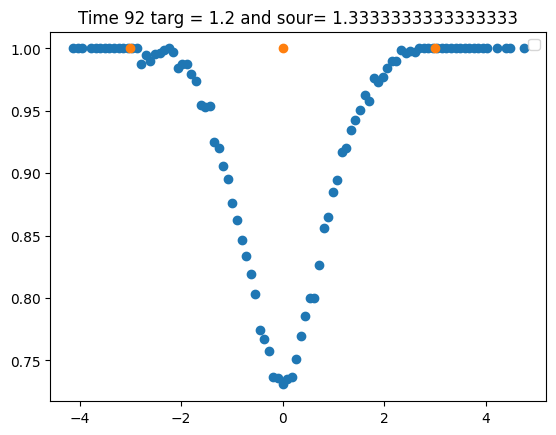

p ratio.         0.839527428150177 std 0.25004303455352783
Time 92 swap btwn source 1.33 and target 1.20 accept 0.84 
 diff 1.060596227645874


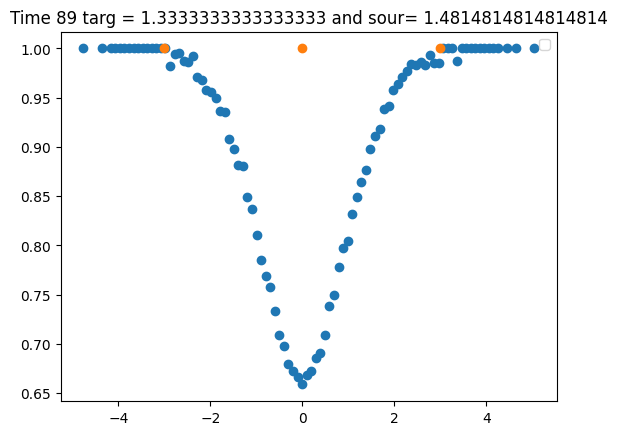

p ratio.         0.794501543045044 std 0.29669347405433655
Time 89 swap btwn source 1.48 and target 1.33 accept 0.79 
 diff 1.0613430738449097


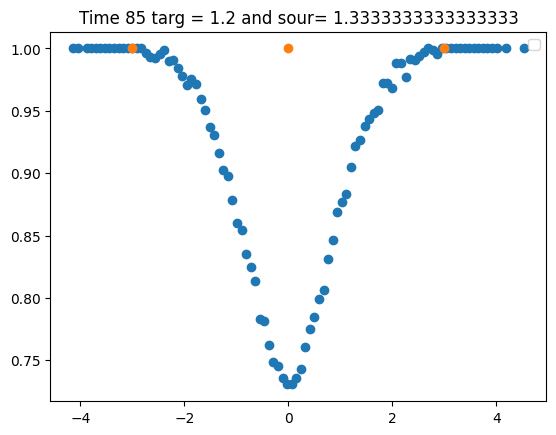

p ratio.         0.8353749513626099 std 0.2510610818862915
Time 85 swap btwn source 1.33 and target 1.20 accept 0.84 
 diff 1.1425424814224243


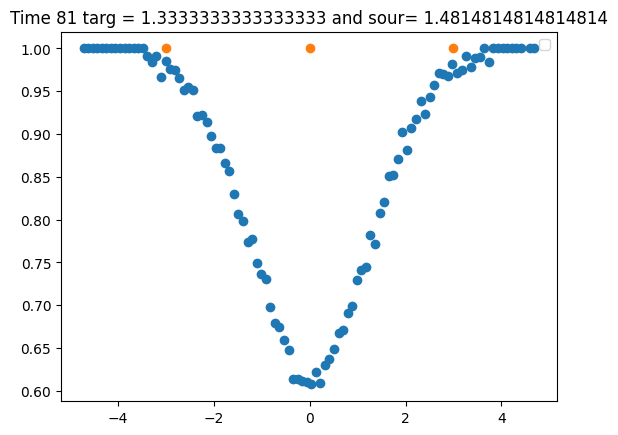

p ratio.         0.7436421513557434 std 0.330741822719574
Time 81 swap btwn source 1.48 and target 1.33 accept 0.74 
 diff 1.0966020822525024


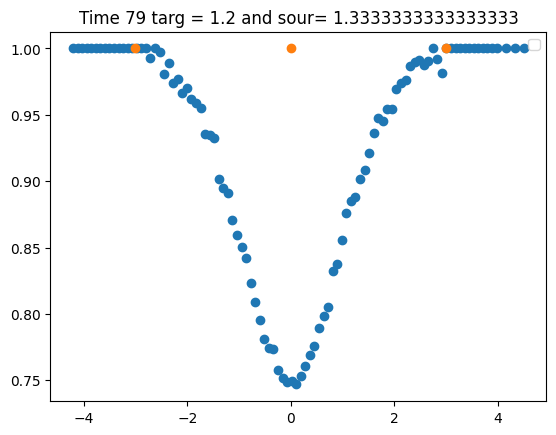

p ratio.         0.8344652652740479 std 0.24582575261592865
Time 79 swap btwn source 1.33 and target 1.20 accept 0.83 
 diff 1.1860439777374268


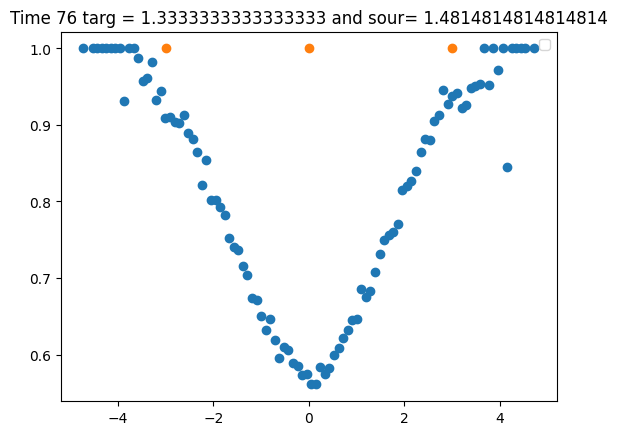

p ratio.         0.6849659085273743 std 0.3532075881958008
Time 76 swap btwn source 1.48 and target 1.33 accept 0.69 
 diff 1.1205518245697021


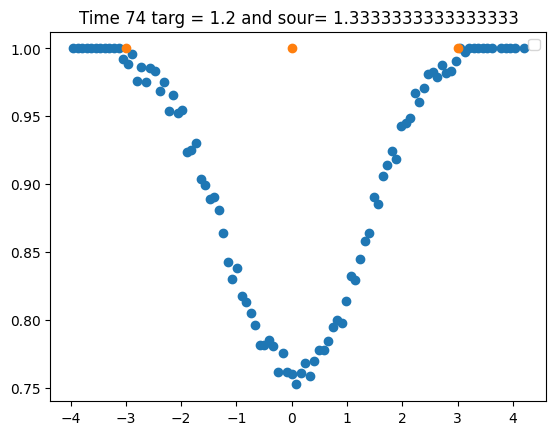

p ratio.         0.8235574960708618 std 0.2511923015117645
Time 74 swap btwn source 1.33 and target 1.20 accept 0.82 
 diff 1.2206199169158936


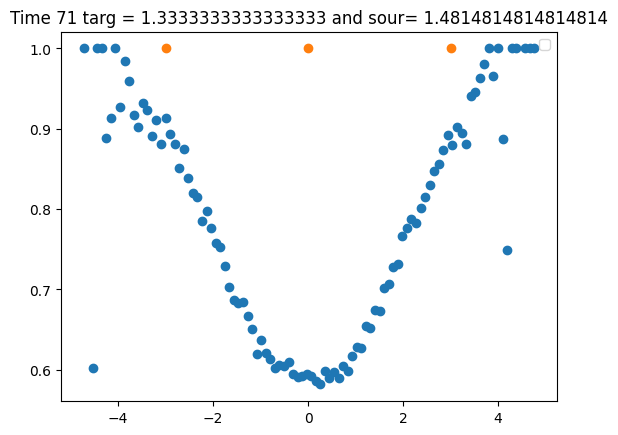

p ratio.         0.6710018515586853 std 0.36013826727867126
Time 71 swap btwn source 1.48 and target 1.33 accept 0.67 
 diff 1.1424745321273804


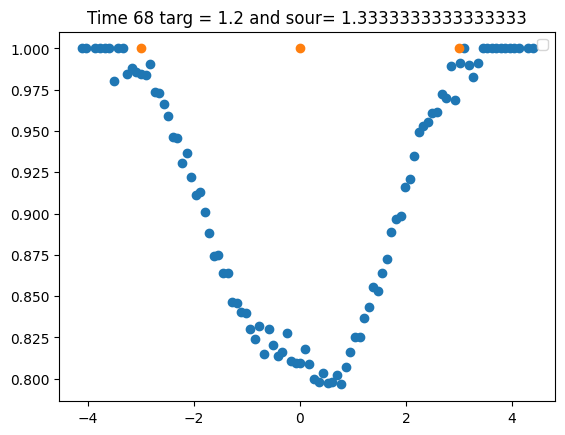

p ratio.         0.8451078534126282 std 0.2435377538204193
Time 68 swap btwn source 1.33 and target 1.20 accept 0.84 
 diff 1.2517927885055542


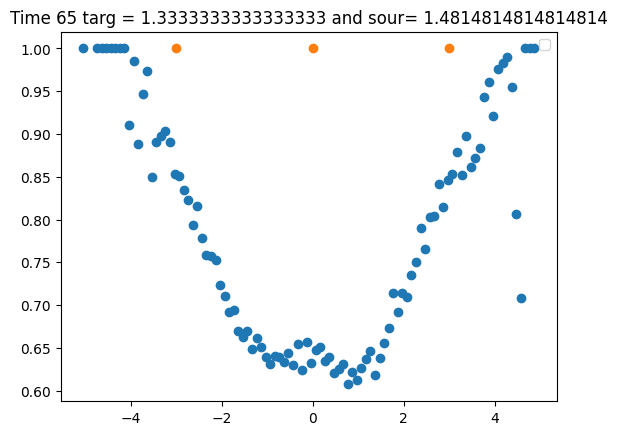

p ratio.         0.6829142570495605 std 0.36533501744270325
Time 65 swap btwn source 1.48 and target 1.33 accept 0.68 
 diff 1.1605803966522217


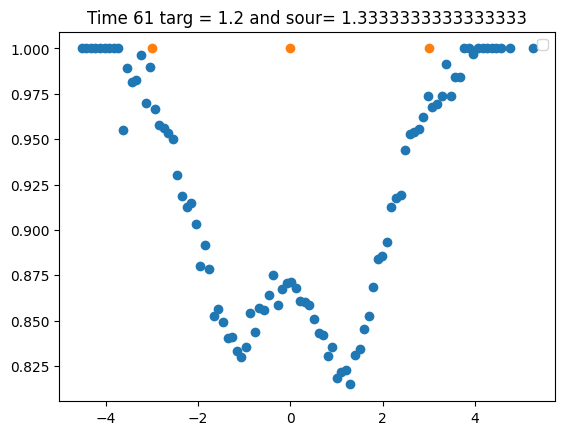

p ratio.         0.8646937012672424 std 0.2349836230278015
Time 61 swap btwn source 1.33 and target 1.20 accept 0.87 
 diff 1.2774776220321655


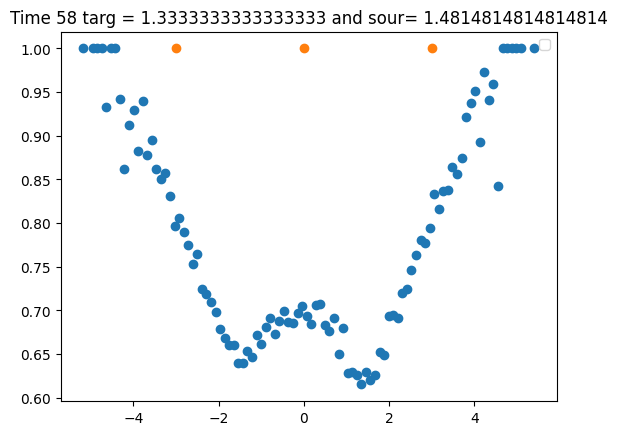

p ratio.         0.6963773369789124 std 0.36779719591140747
Time 58 swap btwn source 1.48 and target 1.33 accept 0.70 
 diff 1.173042893409729


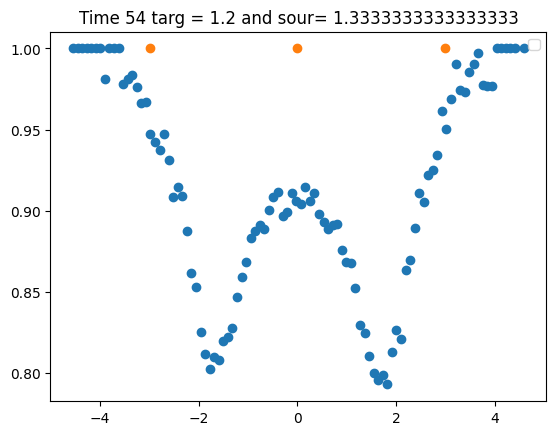

p ratio.         0.8697981238365173 std 0.2219405621290207
Time 54 swap btwn source 1.33 and target 1.20 accept 0.87 
 diff 1.2992539405822754


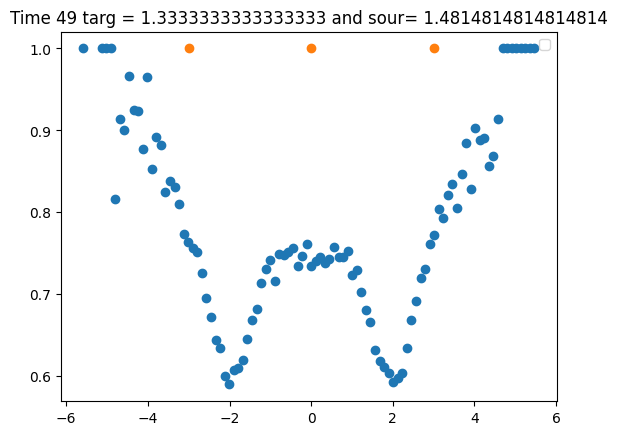

p ratio.         0.7067410945892334 std 0.3605850338935852
Time 49 swap btwn source 1.48 and target 1.33 accept 0.71 
 diff 1.1846210956573486


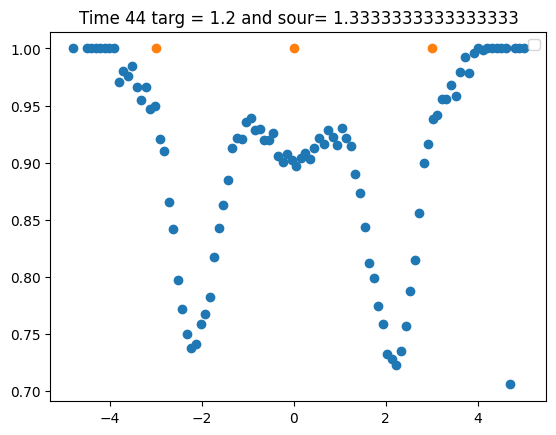

p ratio.         0.8569905757904053 std 0.21909098327159882
Time 44 swap btwn source 1.33 and target 1.20 accept 0.86 


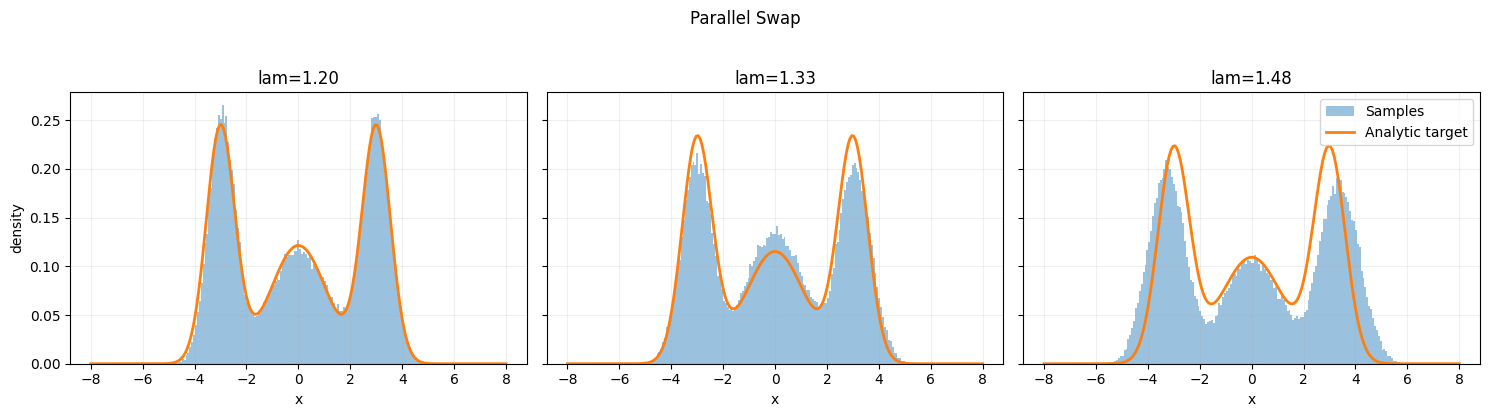

In [4]:
_ = plot_temperature_triptych(
	dataset_name="composed",
	lam=lam,
	n_samples=n_samples,
	n_replicas=n_replicas,
	replica_swaps=True,
	swap_algorithm=swap_algorithm,
)

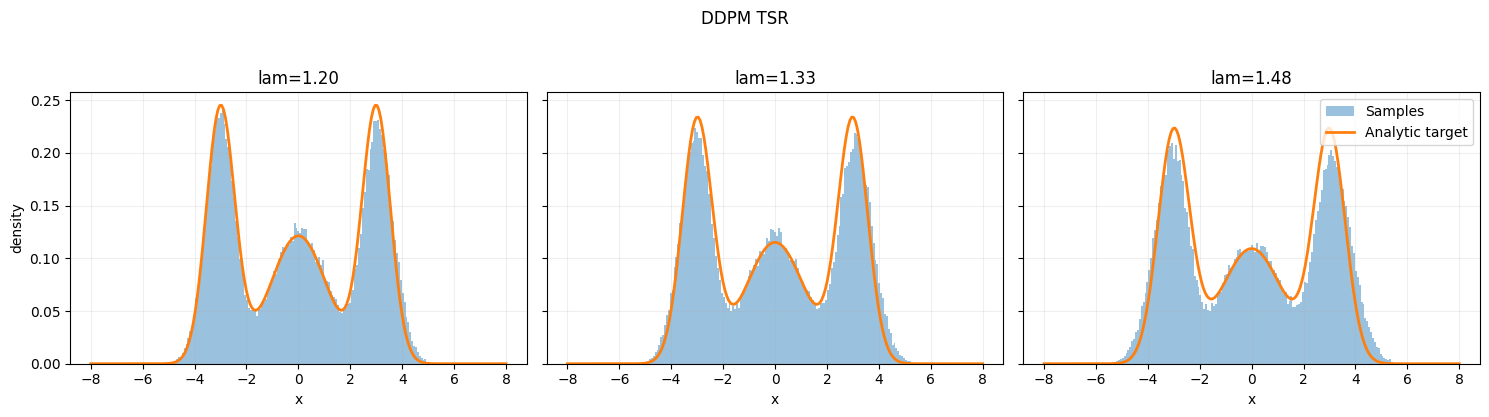

In [5]:
_ = plot_temperature_triptych(
	dataset_name="composed",
	lam=lam,
	n_samples=n_samples,
	n_replicas=n_replicas,
	replica_swaps=False,
	swap_algorithm=swap_algorithm
)

# MNIST Dataset

In [6]:
# _ = plot_temperature_triptych(
# 	dataset_name="mnist",
# 	k=0.5,
# 	n_samples=n_samples,
# 	n_replicas=n_replicas,
# 	replica_swaps=False,
# 	swap_algorithm=swap_algorithm
# )

In [7]:
# _ = plot_temperature_triptych(
# 	dataset_name="mnist",
# 	k=2.0,
# 	n_samples=n_samples,
# 	n_replicas=n_replicas,
# 	replica_swaps=False,
# 	swap_algorithm=swap_algorithm
# )

# Best of N

In [8]:
# _ = plot_temperature_triptych(
# 	dataset_name="composed",
# 	k=k,
# 	n_samples=n_samples,
# 	n_replicas=n_replicas,
# 	replica_swaps=True,
# 	swap_algorithm=swap_algorithm,
# 	best_of_n_runs=4
# )